<a href="https://colab.research.google.com/github/nbhide8/Bhargava-Lab-Project/blob/main/Bhargava_Lab_Project_Data_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Processing Pipeline

**This notebook** scales the data processing pipeline to ~50 patients, after it was built and validated end-to-end on 2 patients in a separate exploratory notebook. The resulting tiles were saved to my personal drive


### Setup

Install dependencies and load the IDC metadata index, filtered down to the eligible patient pool (FFPE slide + binary TIL map available) established during validation.

In [ ]:
!pip install -q idc-index pydicom

from idc_index import index
import pydicom, glob, os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

client = index.IDCClient()
df = client.index

# tcga_luad, whole-slide microscopy images only, tagged by specimen prep type
sm_luad = df[(df['collection_id'] == 'tcga_luad') & (df['Modality'] == 'SM')].copy()
sm_luad['specimen_type'] = sm_luad['SeriesDescription'].apply(
    lambda d: 'FFPE' if isinstance(d, str) and 'FFPE' in d else ('Frozen' if isinstance(d, str) and 'Frozen' in d else 'Other')
)
ffpe_sm = sm_luad[sm_luad['specimen_type'] == 'FFPE']

# Pre-computed binary TIL presence/absence maps (Stony Brook Inception-V4 pipeline, published via IDC)
til_maps = df[(df['collection_id'] == 'tcga_luad') & (df['analysis_result_id'] == 'tcga_sbu_til_maps')]
binary_til = til_maps[til_maps['SeriesDescription'] == 'Stony Brook Inception-V4 Binary TIL Map']

# A usable patient needs both an FFPE slide and a binary TIL map
eligible = set(ffpe_sm['PatientID']) & set(binary_til['PatientID'])
print("Eligible patients:", len(eligible))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.3/77.3 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 104.6 MB/s eta 0:00:00
Eligible patients: 478


### Select the patient set

Random sample of 50 patients from the full eligible pool.

In [ ]:
per_patient_sm = ffpe_sm[ffpe_sm['PatientID'].isin(eligible)].groupby('PatientID')['series_size_MB'].sum()

# sorted() for a deterministic order - a raw Python set's iteration order isn't guaranteed
# stable across runs, which would break reproducibility with a fixed seed below.
rng = np.random.default_rng(42)
scaled_patients = rng.choice(sorted(eligible), 50, replace=False).tolist()

per_patient_til = binary_til[binary_til['PatientID'].isin(scaled_patients)].groupby('PatientID')['series_size_MB'].sum()
total_gb = (per_patient_sm.loc[scaled_patients].sum() + per_patient_til.sum()) / 1024
print(f"Selected 50 patients. Estimated total download size: {total_gb:.1f} GB")

Selected 50 patients. Estimated total download size: 35.0 GB


### Download all 50 patients' data

In [ ]:
sm_uids = ffpe_sm[ffpe_sm['PatientID'].isin(scaled_patients)]['SeriesInstanceUID'].tolist()
til_uids = binary_til[binary_til['PatientID'].isin(scaled_patients)]['SeriesInstanceUID'].tolist()

scaled_download_dir = '/content/scaled_data'
client.download_dicom_series(sm_uids + til_uids, scaled_download_dir)
print("Download complete")

Download complete


### Extract patches for all 50 patients

For each patient, the extraction function does the following:

1. **Choose the WSI level.** Each slide is a multi-resolution pyramid. Skip the thumbnail and pick the level whose pixel spacing is closest to ~1 µm/pixel (chosen by actual spacing, not list position).
2. **Align the TIL map to the slide.** The TIL map is one coarse frame where each pixel covers a 50 µm region. It shares the slide's origin and orientation, so cell `(row, col)` maps to the WSI box `[row·scale, (row+1)·scale)`, where `scale = TIL spacing / WSI spacing`.
3. **Sample cells before decoding anything.** Keep all TIL-positive cells, up to half of a 3,000-patch budget. Fill the rest with randomly chosen TIL-negative cells.
4. **Decode only the tiles needed.** Work out which WSI tiles the sampled cells overlap, then walk the frame stream once, decoding just those tiles and stopping after the highest one needed.
5. **Crop and resize.** Cut each cell's region out of the decoded tiles and resize it to 64×64.
6. **Filter blank tiles.** Drop any patch with pixel `std < 10`. Blank glass and padding are nearly uniform, while real tissue has texture. This is applied after sampling, so a patient can end up with fewer than 3,000 patches.
7. **Save.** Write `patches` and `labels` to one `.npz` per patient on Drive, skipping patients that already exist so runs are resumable.

Each patch's label is the TIL-map value of its cell (1 = TILs present, 0 = absent).

In [ ]:
import io
from pydicom.encaps import generate_pixel_data_frame

TARGET_SPACING_MM = 0.001  # ~1 micron/pixel

def extract_patches_for_patient(patient_id, download_dir, patch_size=64, max_patches=3000, seed=0):
    """Sample TIL grid cells FIRST (all positives available, up to half the budget, negatives
    fill the rest), then decode only the WSI tiles those samples need - in a SINGLE pass over
    the frame stream.

    (Fix #1: calling generate_pixel_data_frame() separately per tile re-parses the raw byte
    stream from frame 0 every time, so "selective" decoding ended up no faster than decoding
    the whole slide. Collecting every needed tile index up front and walking the stream once,
    caching only those frames, avoids the wasted work.

    Fix #2: the WSI level was originally picked by its position in a sorted list
    (`volume_levels[1]`, "the second-smallest non-thumbnail level"), assuming that always
    corresponds to ~1 micron/pixel. Different slides can have pyramids with different numbers
    of levels or different spacing between them, so list position doesn't reliably mean the
    same physical resolution for every patient - some patients ended up with a much coarser
    level, producing tiny raw crops that got aggressively upscaled to patch_size (blurry
    patches). Now the level is picked by whichever has pixel spacing closest to a target
    resolution, which is robust regardless of a given file's pyramid structure.)"""
    rng = np.random.default_rng(seed)

    sm_dir = glob.glob(f'{download_dir}/tcga_luad/{patient_id}/*/SM_*')[0]
    sm_paths = [os.path.join(sm_dir, f) for f in os.listdir(sm_dir)]
    headers = [pydicom.dcmread(p, stop_before_pixels=True) for p in sm_paths]
    non_thumb = [(p, d) for p, d in zip(sm_paths, headers) if 'THUMBNAIL' not in d.ImageType]

    def spacing_of(d):
        return float(d.SharedFunctionalGroupsSequence[0].PixelMeasuresSequence[0].PixelSpacing[0])

    level_path, _ = min(non_thumb, key=lambda pd: abs(spacing_of(pd[1]) - TARGET_SPACING_MM))
    level = pydicom.dcmread(level_path)  # raw PixelData bytes only - not decoded yet

    seg_path = glob.glob(f'{download_dir}/tcga_luad/{patient_id}/*/SEG_*/*.dcm')[0]
    seg = pydicom.dcmread(seg_path)
    til_map = seg.pixel_array

    seg_spacing = float(seg.SharedFunctionalGroupsSequence[0].PixelMeasuresSequence[0].PixelSpacing[0])
    wsi_spacing = spacing_of(level)
    scale = seg_spacing / wsi_spacing

    pos_cells = list(zip(*np.where(til_map == 1)))
    neg_cells = list(zip(*np.where(til_map == 0)))
    rng.shuffle(pos_cells)
    rng.shuffle(neg_cells)

    n_pos = min(len(pos_cells), max_patches // 2)
    n_neg = min(len(neg_cells), max_patches - n_pos)
    sampled = [(r, c, 1) for r, c in pos_cells[:n_pos]] + [(r, c, 0) for r, c in neg_cells[:n_neg]]

    tile_rows, tile_cols = level.Rows, level.Columns
    total_rows, total_cols = level.TotalPixelMatrixRows, level.TotalPixelMatrixColumns
    n_tile_cols = -(-total_cols // tile_cols)

    # Pass 1: for every sampled cell, work out its pixel box and which tiles it needs -
    # no decoding yet, just bookkeeping.
    cell_boxes = []  # (label, x0c, y0c, x1c, y1c, tile_r0, tile_c0, tile_r1, tile_c1)
    needed_tiles = set()
    for row, col, label in sampled:
        y0, y1 = int(row * scale), int((row + 1) * scale)
        x0, x1 = int(col * scale), int((col + 1) * scale)
        x0c, y0c = max(x0, 0), max(y0, 0)
        x1c, y1c = min(x1, total_cols), min(y1, total_rows)
        if x1c <= x0c or y1c <= y0c:
            continue
        tile_c0, tile_c1 = x0c // tile_cols, (x1c - 1) // tile_cols
        tile_r0, tile_r1 = y0c // tile_rows, (y1c - 1) // tile_rows
        for r in range(tile_r0, tile_r1 + 1):
            for c in range(tile_c0, tile_c1 + 1):
                needed_tiles.add(r * n_tile_cols + c)
        cell_boxes.append((label, x0c, y0c, x1c, y1c, tile_r0, tile_c0, tile_r1, tile_c1))

    # Pass 2: walk the frame stream ONCE, decoding and caching only the tiles we actually need.
    frame_cache = {}
    max_needed = max(needed_tiles) if needed_tiles else -1
    for idx, frame_bytes in enumerate(generate_pixel_data_frame(level.PixelData, level.NumberOfFrames)):
        if idx in needed_tiles:
            frame_cache[idx] = np.array(Image.open(io.BytesIO(frame_bytes)))
        if idx >= max_needed:
            break

    # Pass 3: assemble each cell's patch from the cached tiles.
    patches, labels = [], []
    for label, x0c, y0c, x1c, y1c, tile_r0, tile_c0, tile_r1, tile_c1 in cell_boxes:
        canvas = np.zeros(((tile_r1 - tile_r0 + 1) * tile_rows, (tile_c1 - tile_c0 + 1) * tile_cols, 3), dtype=np.uint8)
        for r in range(tile_r0, tile_r1 + 1):
            for c in range(tile_c0, tile_c1 + 1):
                idx = r * n_tile_cols + c
                if idx in frame_cache:
                    rr, cc = r - tile_r0, c - tile_c0
                    canvas[rr*tile_rows:(rr+1)*tile_rows, cc*tile_cols:(cc+1)*tile_cols] = frame_cache[idx]
        off_x, off_y = x0c - tile_c0 * tile_cols, y0c - tile_r0 * tile_rows
        crop = canvas[off_y:off_y + (y1c - y0c), off_x:off_x + (x1c - x0c)]
        patch = np.array(Image.fromarray(crop).resize((patch_size, patch_size)))
        if patch.std() < 10:  # texture-based tissue filter
            continue
        patches.append(patch)
        labels.append(label)

    return np.stack(patches), np.array(labels)

print("Functions defined (fixed: single-pass frame decoding + spacing-based level selection)")

Functions defined (fixed: single-pass frame decoding + spacing-based level selection)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
save_dir = '/content/drive/MyDrive/TCGA_LUAD_DATA/scaled_patches'
os.makedirs(save_dir, exist_ok=True)
print("Save dir ready:", save_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Save dir ready: /content/drive/MyDrive/TCGA_LUAD_DATA/scaled_patches


In [ ]:
import time

results_summary = []
start = time.time()

for i, patient_id in enumerate(scaled_patients):
    out_path = os.path.join(save_dir, f'{patient_id}.npz')
    if os.path.exists(out_path):
        print(f"[{i+1}/50] {patient_id}: already done, skipping")
        continue
    try:
        patches, labels = extract_patches_for_patient(patient_id, scaled_download_dir)
        np.savez_compressed(out_path, patches=patches, labels=labels)
        results_summary.append((patient_id, len(labels), labels.mean(), None))
        print(f"[{i+1}/50] {patient_id}: {len(labels)} patches, {labels.mean():.2f} positive rate "
              f"({time.time()-start:.0f}s elapsed)")
    except Exception as e:
        results_summary.append((patient_id, 0, None, str(e)))
        print(f"[{i+1}/50] {patient_id}: FAILED - {e}")

print(f"\nDone in {time.time()-start:.0f}s. {sum(1 for r in results_summary if r[3] is None)}/50 succeeded.")

[1/50] TCGA-55-7728: 1825 patches, 0.52 positive rate (18s elapsed)
[2/50] TCGA-55-A48Y: 1673 patches, 0.40 positive rate (36s elapsed)
[3/50] TCGA-55-8096: 2012 patches, 0.37 positive rate (54s elapsed)
[4/50] TCGA-38-4625: 2144 patches, 0.70 positive rate (87s elapsed)
[5/50] TCGA-S2-AA1A: 2541 patches, 0.59 positive rate (101s elapsed)
[6/50] TCGA-MP-A4TE: 2244 patches, 0.67 positive rate (114s elapsed)
[7/50] TCGA-73-4676: 2336 patches, 0.64 positive rate (193s elapsed)
[8/50] TCGA-78-7166: 2513 patches, 0.60 positive rate (248s elapsed)
[9/50] TCGA-50-5068: 2354 patches, 0.64 positive rate (312s elapsed)
[10/50] TCGA-55-8302: 1170 patches, 0.33 positive rate (317s elapsed)
[11/50] TCGA-55-6984: 2319 patches, 0.65 positive rate (370s elapsed)
[12/50] TCGA-78-7156: 2348 patches, 0.64 positive rate (422s elapsed)
[13/50] TCGA-55-7907: 2262 patches, 0.66 positive rate (457s elapsed)
[14/50] TCGA-05-5429: 884 patches, 0.00 positive rate (464s elapsed)
[15/50] TCGA-86-6851: 2333 patches

## Gather info about dataset

In [ ]:
files = sorted(glob.glob(os.path.join(save_dir, '*.npz')))
print(f"Patients saved: {len(files)}/50")

total_patches = 0
total_positive = 0
total_bytes = 0
per_patient = []
for f in files:
    d = np.load(f)
    n = len(d['labels'])
    pos = d['labels'].sum()
    total_patches += n
    total_positive += pos
    total_bytes += os.path.getsize(f)
    per_patient.append((os.path.basename(f), n, pos / n))

print(f"Total patches: {total_patches}")
print(f"Overall positive rate: {total_positive/total_patches:.3f}")
print(f"Total Drive storage used: {total_bytes/1024**3:.2f} GB")
print(f"\nPer-patient patch count range: {min(p[1] for p in per_patient)} - {max(p[1] for p in per_patient)}")
print(f"Per-patient positive rate range: {min(p[2] for p in per_patient):.2f} - {max(p[2] for p in per_patient):.2f}")

Patients saved: 50/50
Total patches: 101242
Overall positive rate: 0.618
Total Drive storage used: 1.06 GB

Per-patient patch count range: 505 - 2662
Per-patient positive rate range: 0.00 - 0.86


/tmp/ipykernel_758/2951628860.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


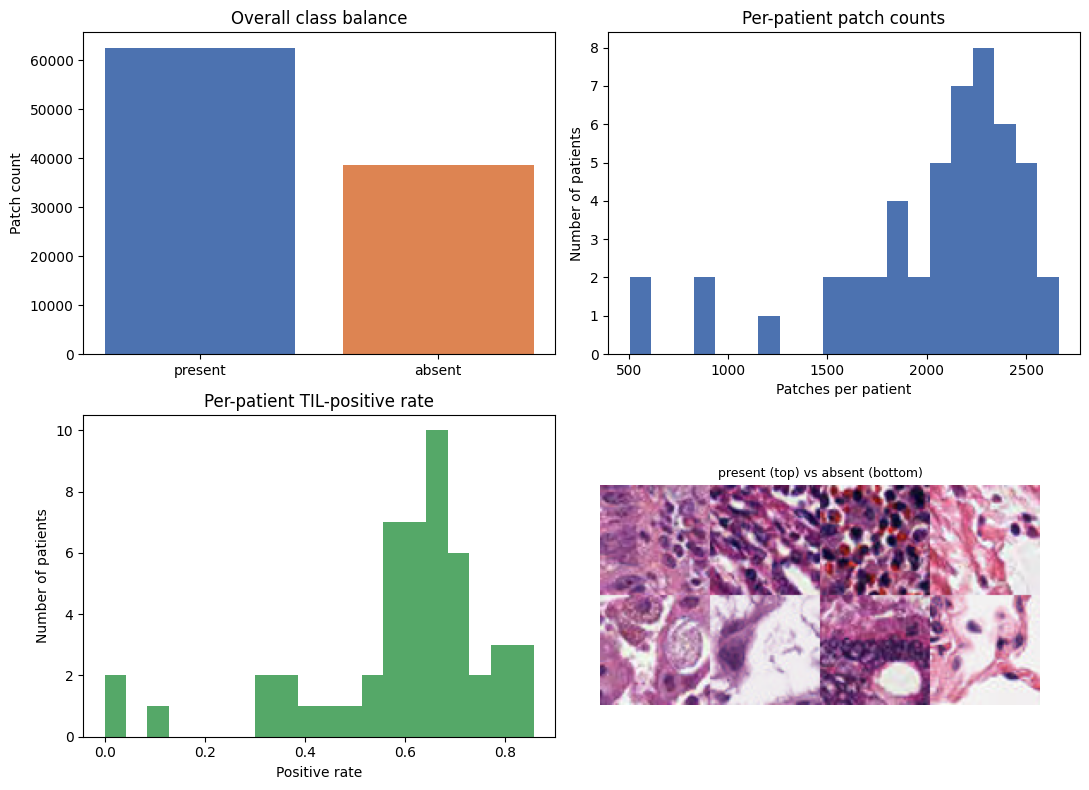

Total patients: 50, total patches: 101242, overall positive rate: 0.618


In [ ]:
### Final summary: dataset overview

files = sorted(glob.glob(os.path.join(save_dir, '*.npz')))

per_patient_counts, per_patient_rates = [], []
all_sample_patches, all_sample_labels = [], []
rng = np.random.default_rng(0)

for f in files:
    d = np.load(f)
    labels = d['labels']
    per_patient_counts.append(len(labels))
    per_patient_rates.append(labels.mean())
    # grab a few patches per patient for the montage sample, without loading everything
    idx = rng.choice(len(labels), size=min(20, len(labels)), replace=False)
    all_sample_patches.append(d['patches'][idx])
    all_sample_labels.append(labels[idx])

all_sample_patches = np.concatenate(all_sample_patches)
all_sample_labels = np.concatenate(all_sample_labels)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# Overall class balance
total_pos = sum(c * r for c, r in zip(per_patient_counts, per_patient_rates))
total_neg = sum(per_patient_counts) - total_pos
axes[0, 0].bar(['present', 'absent'], [total_pos, total_neg], color=['#4C72B0', '#DD8452'])
axes[0, 0].set_ylabel('Patch count')
axes[0, 0].set_title('Overall class balance')

# Per-patient patch count distribution
axes[0, 1].hist(per_patient_counts, bins=20, color='#4C72B0')
axes[0, 1].set_xlabel('Patches per patient')
axes[0, 1].set_ylabel('Number of patients')
axes[0, 1].set_title('Per-patient patch counts')

# Per-patient positive rate distribution
axes[1, 0].hist(per_patient_rates, bins=20, color='#55A868')
axes[1, 0].set_xlabel('Positive rate')
axes[1, 0].set_ylabel('Number of patients')
axes[1, 0].set_title('Per-patient TIL-positive rate')

# Sample patch montage (present vs absent), pooled across patients
pos_idx = rng.choice(np.where(all_sample_labels == 1)[0], 4, replace=False)
neg_idx = rng.choice(np.where(all_sample_labels == 0)[0], 4, replace=False)
axes[1, 1].axis('off')
inset = fig.add_axes([0.55, 0.05, 0.4, 0.4])
inset.axis('off')
montage = np.concatenate([np.concatenate([all_sample_patches[i] for i in pos_idx], axis=1),
                           np.concatenate([all_sample_patches[i] for i in neg_idx], axis=1)], axis=0)
inset.imshow(montage)
inset.set_title('present (top) vs absent (bottom)', fontsize=9)

plt.tight_layout()
plt.savefig('/content/dataset_summary.png', dpi=100)
plt.show()

print(f"Total patients: {len(files)}, total patches: {sum(per_patient_counts)}, "
      f"overall positive rate: {total_pos/sum(per_patient_counts):.3f}")
